# Uploading

In [2]:
!pip install -q kagglehub pandas numpy matplotlib nltk evaluate rouge_score sacrebleu

In [3]:
import os
import re
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import kagglehub

In [4]:
dataset_path = kagglehub.dataset_download("marawanxmamdouh/dialogsum")

print("Dataset path:", dataset_path)

100%|██████████| 8.05M/8.05M [00:00<00:00, 105MB/s]

Extracting files...


Dataset path: /root/.cache/kagglehub/datasets/marawanxmamdouh/dialogsum/versions/4


In [5]:
csv_files = []

for root, dirs, files in os.walk(dataset_path):
    for file in files:
        if file.endswith(".csv"):
            csv_files.append(os.path.join(root, file))

csv_files

dataframes = {}

for file_path in csv_files:
    file_name = os.path.basename(file_path)
    df_name = file_name.replace(".csv", "")
    dataframes[df_name] = pd.read_csv(file_path)

    print(df_name, dataframes[df_name].shape)

test (1500, 4)
hiddentest_dialogue (100, 2)
validation (500, 4)
train (12460, 4)
hiddentest_topic (100, 2)


In [6]:
train_df = dataframes["train"]
val_df = dataframes["validation"]
test_df = dataframes["test"]

train_df.head()

,id,dialogue,summary,topic
0,train_0,"#Person1#: Hi, Mr. Smith. I'm Doctor Hawkins. ...","Mr. Smith's getting a check-up, and Doctor Haw...",get a check-up
1,train_1,"#Person1#: Hello Mrs. Parker, how have you bee...",Mrs Parker takes Ricky for his vaccines. Dr. P...,vaccines
2,train_2,"#Person1#: Excuse me, did you see a set of key...",#Person1#'s looking for a set of keys and asks...,find keys
3,train_3,#Person1#: Why didn't you tell me you had a gi...,#Person1#'s angry because #Person2# didn't tel...,have a girlfriend
4,train_4,"#Person1#: Watsup, ladies! Y'll looking'fine t...",Malik invites Nikki to dance. Nikki agrees if ...,dance


# EDA

- id        — технический идентификатор записи
- dialogue  — сам диалог, входные данные для модели
- summary   — правильный ответ / эталонное summary
- topic     — тема диалога

In [7]:
print("Train shape:", train_df.shape)
print("Validation shape:", val_df.shape)
print("Test shape:", test_df.shape)

Train shape: (12460, 4)
Validation shape: (500, 4)
Test shape: (1500, 4)


In [8]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12460 entries, 0 to 12459
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   id        12460 non-null  object
 1   dialogue  12460 non-null  object
 2   summary   12460 non-null  object
 3   topic     12460 non-null  object
dtypes: object(4)
memory usage: 389.5+ KB


In [9]:
example = train_df.iloc[0]

print("ID:")
print(example["id"])

print("\nTOPIC:")
print(example["topic"])

print("\nDIALOGUE:")
print(example["dialogue"])

print("\nREFERENCE SUMMARY:")
print(example["summary"])

ID:
train_0

TOPIC:
get a check-up

DIALOGUE:
#Person1#: Hi, Mr. Smith. I'm Doctor Hawkins. Why are you here today?
#Person2#: I found it would be a good idea to get a check-up.
#Person1#: Yes, well, you haven't had one for 5 years. You should have one every year.
#Person2#: I know. I figure as long as there is nothing wrong, why go see the doctor?
#Person1#: Well, the best way to avoid serious illnesses is to find out about them early. So try to come at least once a year for your own good.
#Person2#: Ok.
#Person1#: Let me see here. Your eyes and ears look fine. Take a deep breath, please. Do you smoke, Mr. Smith?
#Person2#: Yes.
#Person1#: Smoking is the leading cause of lung cancer and heart disease, you know. You really should quit.
#Person2#: I've tried hundreds of times, but I just can't seem to kick the habit.
#Person1#: Well, we have classes and some medications that might help. I'll give you more information before you leave.
#Person2#: Ok, thanks doctor.

REFERENCE SUMMARY:
Mr

In [10]:
def count_words(text):
    return len(str(text).split())

def count_chars(text):
    return len(str(text))

def count_turns(text):
    text = str(text)
    return text.count("#Person")

def add_length_features(df):
    df = df.copy()
    df["dialogue_word_len"] = df["dialogue"].apply(count_words)
    df["summary_word_len"] = df["summary"].apply(count_words)
    df["dialogue_char_len"] = df["dialogue"].apply(count_chars)
    df["summary_char_len"] = df["summary"].apply(count_chars)
    df["turns_count"] = df["dialogue"].apply(count_turns)
    df["compression_ratio"] = df["summary_word_len"] / df["dialogue_word_len"]
    return df

train_df = add_length_features(train_df)
val_df = add_length_features(val_df)
test_df = add_length_features(test_df)

In [11]:
eda_columns = [
    "dialogue_word_len",
    "summary_word_len",
    "dialogue_char_len",
    "summary_char_len",
    "turns_count",
    "compression_ratio"
]

train_df[eda_columns].describe()

,dialogue_word_len,summary_word_len,dialogue_char_len,summary_char_len,turns_count,compression_ratio
count,12460.000000,12460.000000,12460.000000,12460.000000,12460.000000,12460.000000
mean,130.986998,22.867657,738.281300,140.733547,9.494222,0.185301
std,70.976634,10.705946,396.544752,65.133972,4.157145,0.049095
min,40.000000,5.000000,190.000000,31.000000,2.000000,0.051923
25%,85.000000,15.000000,485.000000,95.000000,7.000000,0.155738
50%,116.000000,21.000000,653.000000,129.000000,9.000000,0.181086
75%,163.000000,28.000000,916.000000,173.000000,12.000000,0.205556
max,985.000000,153.000000,5178.000000,1039.000000,61.000000,0.775510


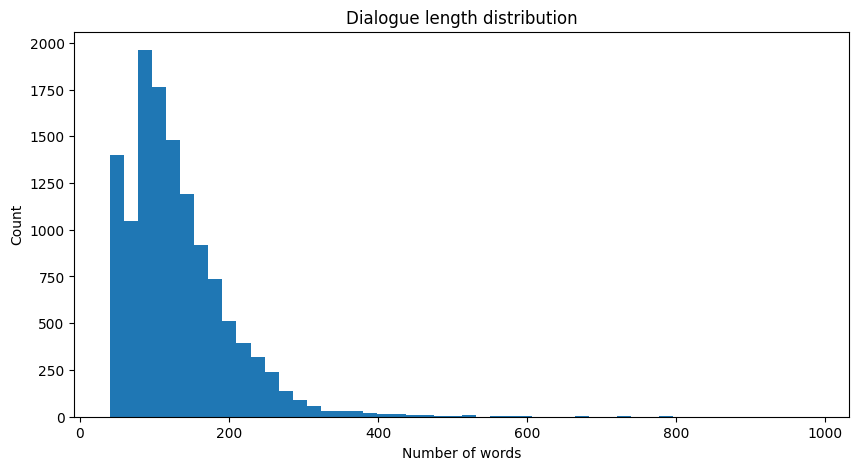

In [12]:
plt.figure(figsize=(10, 5))
plt.hist(train_df["dialogue_word_len"], bins=50)
plt.title("Dialogue length distribution")
plt.xlabel("Number of words")
plt.ylabel("Count")
plt.show()

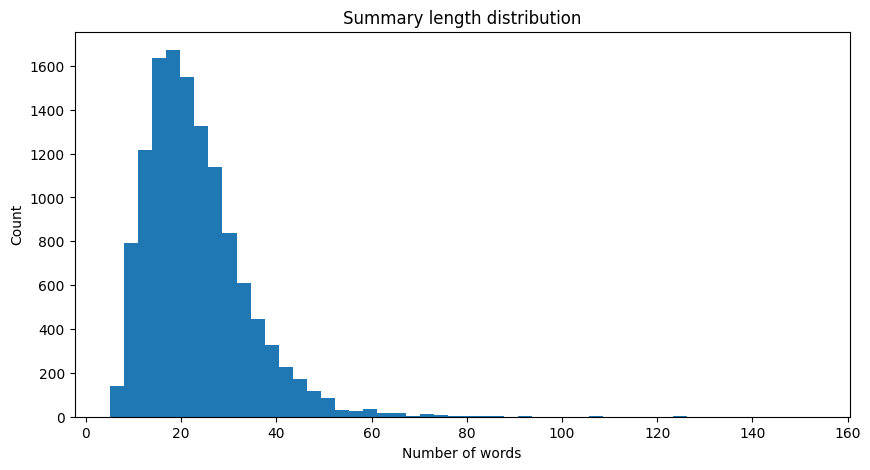

In [13]:
plt.figure(figsize=(10, 5))
plt.hist(train_df["summary_word_len"], bins=50)
plt.title("Summary length distribution")
plt.xlabel("Number of words")
plt.ylabel("Count")
plt.show()

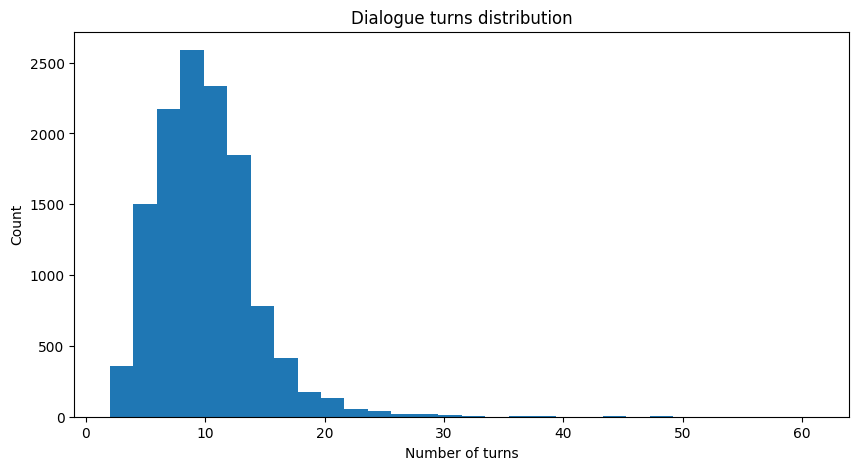

In [14]:
plt.figure(figsize=(10, 5))
plt.hist(train_df["turns_count"], bins=30)
plt.title("Dialogue turns distribution")
plt.xlabel("Number of turns")
plt.ylabel("Count")
plt.show()

In [16]:
train_df["topic"].value_counts().head(20)



,count
topic,
shopping,174
job interview,161
daily casual talk,125
phone call,89
order food,79
interview,77
social meeting,56
business talk,48
see a doctor,46


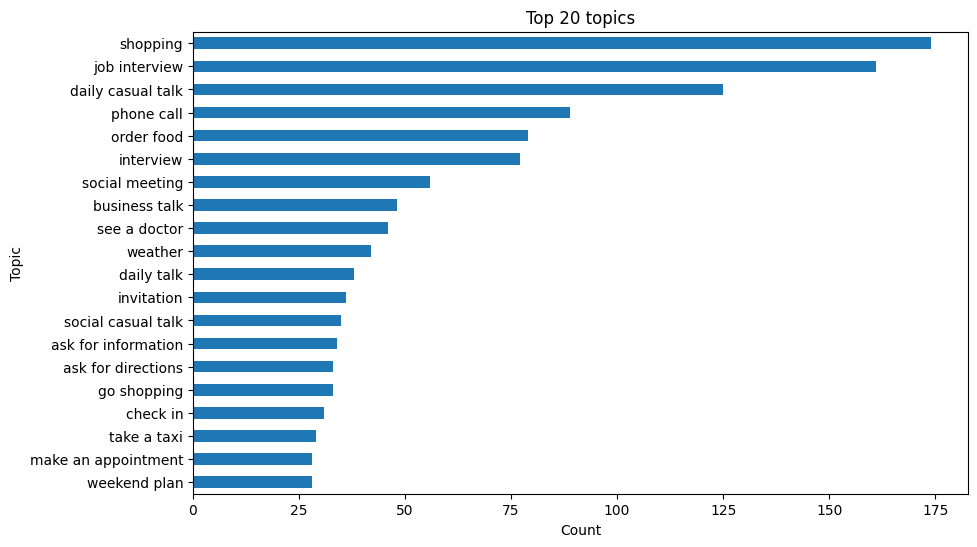

In [17]:
top_topics = train_df["topic"].value_counts().head(20)

plt.figure(figsize=(10, 6))
top_topics.sort_values().plot(kind="barh")
plt.title("Top 20 topics")
plt.xlabel("Count")
plt.ylabel("Topic")
plt.show()

# Rule-based baseline

In [20]:
import re

def split_into_sentences(text):
    text = str(text).replace("\n", " ")
    text = re.sub(r"\s+", " ", text).strip()

    sentences = re.split(r"(?<=[.!?])\s+", text)
    sentences = [s.strip() for s in sentences if s.strip()]

    return sentences

def first_last_sentence_baseline(dialogue):
    sentences = split_into_sentences(dialogue)

    if len(sentences) == 0:
        return ""

    if len(sentences) == 1:
        return sentences[0]

    return sentences[0] + " " + sentences[-1]

In [21]:
example_dialogue = test_df.iloc[0]["dialogue"]
reference_summary = test_df.iloc[0]["summary"]
baseline_summary = first_last_sentence_baseline(example_dialogue)

print("DIALOGUE:")
print(example_dialogue)

print("\nREFERENCE SUMMARY:")
print(reference_summary)

print("\nBASELINE SUMMARY:")
print(baseline_summary)

DIALOGUE:
#Person1#: Ms. Dawson, I need you to take a dictation for me.
#Person2#: Yes, sir...
#Person1#: This should go out as an intra-office memorandum to all employees by this afternoon. Are you ready?
#Person2#: Yes, sir. Go ahead.
#Person1#: Attention all staff... Effective immediately, all office communications are restricted to email correspondence and official memos. The use of Instant Message programs by employees during working hours is strictly prohibited.
#Person2#: Sir, does this apply to intra-office communications only? Or will it also restrict external communications?
#Person1#: It should apply to all communications, not only in this office between employees, but also any outside communications.
#Person2#: But sir, many employees use Instant Messaging to communicate with their clients.
#Person1#: They will just have to change their communication methods. I don't want any - one using Instant Messaging in this office. It wastes too much time! Now, please continue with th

In [22]:
baseline_df = test_df[["id", "dialogue", "summary", "topic"]].copy()

baseline_df["baseline_summary"] = baseline_df["dialogue"].apply(first_last_sentence_baseline)

baseline_df.head()

,id,dialogue,summary,topic,baseline_summary
0,test_0_1,"#Person1#: Ms. Dawson, I need you to take a di...",Ms. Dawson helps #Person1# to write a memo to ...,communication method,#Person1#: Ms. Please get this memo typed up a...
1,test_0_2,"#Person1#: Ms. Dawson, I need you to take a di...",In order to prevent employees from wasting tim...,company policy,#Person1#: Ms. Please get this memo typed up a...
2,test_0_3,"#Person1#: Ms. Dawson, I need you to take a di...",Ms. Dawson takes a dictation for #Person1# abo...,dictation,#Person1#: Ms. Please get this memo typed up a...
3,test_1_1,#Person1#: You're finally here! What took so l...,#Person2# arrives late because of traffic jam....,public transportation,#Person1#: You're finally here! #Person2#: Yes...
4,test_1_2,#Person1#: You're finally here! What took so l...,#Person2# decides to follow #Person1#'s sugges...,transportation,#Person1#: You're finally here! #Person2#: Yes...


In [23]:
for i in range(3):
    row = baseline_df.iloc[i]

    print("=" * 100)
    print("TOPIC:", row["topic"])

    print("\nREFERENCE SUMMARY:")
    print(row["summary"])

    print("\nBASELINE SUMMARY:")
    print(row["baseline_summary"])

TOPIC: communication method

REFERENCE SUMMARY:
Ms. Dawson helps #Person1# to write a memo to inform every employee that they have to change the communication method and should not use Instant Messaging anymore.

BASELINE SUMMARY:
#Person1#: Ms. Please get this memo typed up and distributed to all employees before 4 pm.
TOPIC: company policy

REFERENCE SUMMARY:
In order to prevent employees from wasting time on Instant Message programs, #Person1# decides to terminate the use of those programs and asks Ms. Dawson to send out a memo to all employees by the afternoon.

BASELINE SUMMARY:
#Person1#: Ms. Please get this memo typed up and distributed to all employees before 4 pm.
TOPIC: dictation

REFERENCE SUMMARY:
Ms. Dawson takes a dictation for #Person1# about prohibiting the use of Instant Message programs in the office. They argue about its reasonability but #Person1# still insists.

BASELINE SUMMARY:
#Person1#: Ms. Please get this memo typed up and distributed to all employees before 4

In [24]:
import evaluate

rouge_metric = evaluate.load("rouge")
sacrebleu_metric = evaluate.load("sacrebleu")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


In [25]:
predictions = baseline_df["baseline_summary"].tolist()
references = baseline_df["summary"].tolist()

rouge_results = rouge_metric.compute(
    predictions=predictions,
    references=references
)

bleu_results = sacrebleu_metric.compute(
    predictions=predictions,
    references=[[ref] for ref in references]
)

baseline_metrics = {
    "method": "first_last_sentence_baseline",
    "bleu": bleu_results["score"],
    "rouge1": rouge_results["rouge1"],
    "rouge2": rouge_results["rouge2"],
    "rougeL": rouge_results["rougeL"],
    "rougeLsum": rouge_results["rougeLsum"],
}

baseline_metrics

{'method': 'first_last_sentence_baseline',
 'bleu': 6.5236427786031586,
 'rouge1': np.float64(0.20435663730451054),
 'rouge2': np.float64(0.038428824319130236),
 'rougeL': np.float64(0.17423108923416744),
 'rougeLsum': np.float64(0.17403779757302512)}

In [26]:
baseline_metrics_df = pd.DataFrame([baseline_metrics])
baseline_metrics_df

,method,bleu,rouge1,rouge2,rougeL,rougeLsum
0,first_last_sentence_baseline,6.523643,0.204357,0.038429,0.174231,0.174038


In [27]:
import os

os.makedirs("outputs/metrics", exist_ok=True)
os.makedirs("outputs/predictions", exist_ok=True)

baseline_df.to_csv(
    "outputs/predictions/baseline_predictions.csv",
    index=False
)

baseline_metrics_df.to_csv(
    "outputs/metrics/baseline_metrics.csv",
    index=False
)

print("Saved files:")
print("outputs/predictions/baseline_predictions.csv")
print("outputs/metrics/baseline_metrics.csv")

Saved files:
outputs/predictions/baseline_predictions.csv
outputs/metrics/baseline_metrics.csv


In [28]:
from google.colab import files

files.download("outputs/metrics/baseline_metrics.csv")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>